In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import joblib
import os

os.makedirs('../data/processed', exist_ok=True)


In [2]:
# Veri yükle
df = pd.read_csv('../data/processed/telco_cleaned.csv')


In [3]:
# customerID düşür
df.drop('customerID', axis=1, inplace=True)

In [4]:
# Kategorik kolonları encode et
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_5042/1829971558.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [5]:
# X / y ayır
X = df.drop('Churn', axis=1)
y = df['Churn']


In [6]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
# XGBoost modeli
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='auc'
)
model.fit(X_train, y_train)

# Değerlendirme
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

ROC-AUC: 0.8427


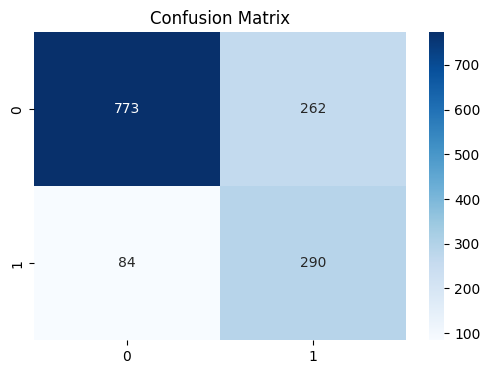

In [8]:
# Confusion matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('../data/processed/confusion_matrix.png')
plt.show()


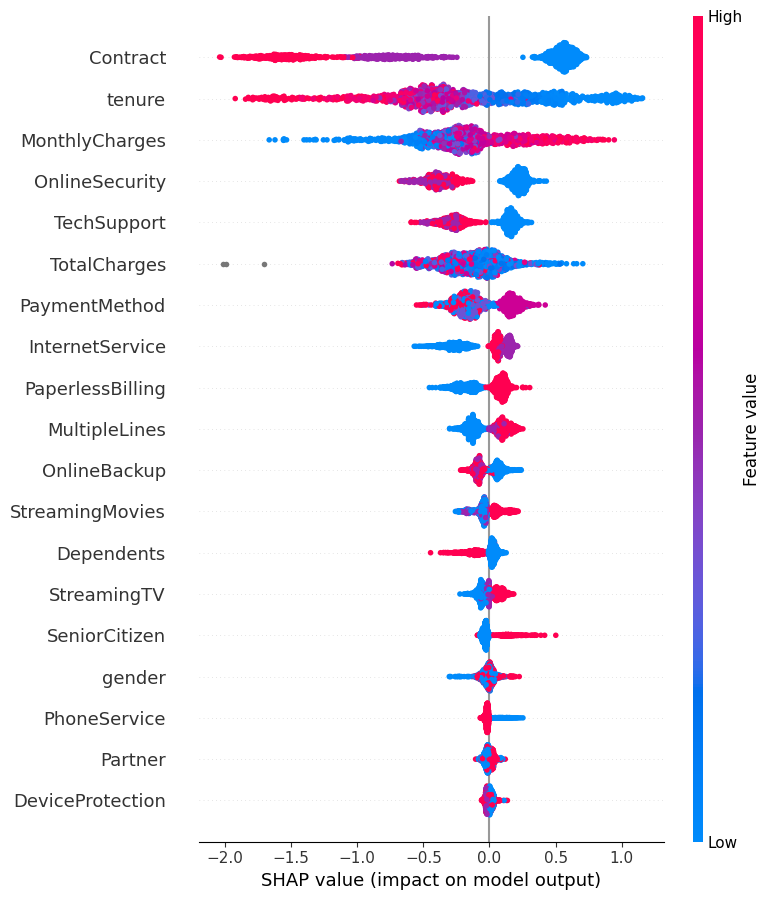

In [9]:
# SHAP - açıklanabilir AI
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png')
plt.show()

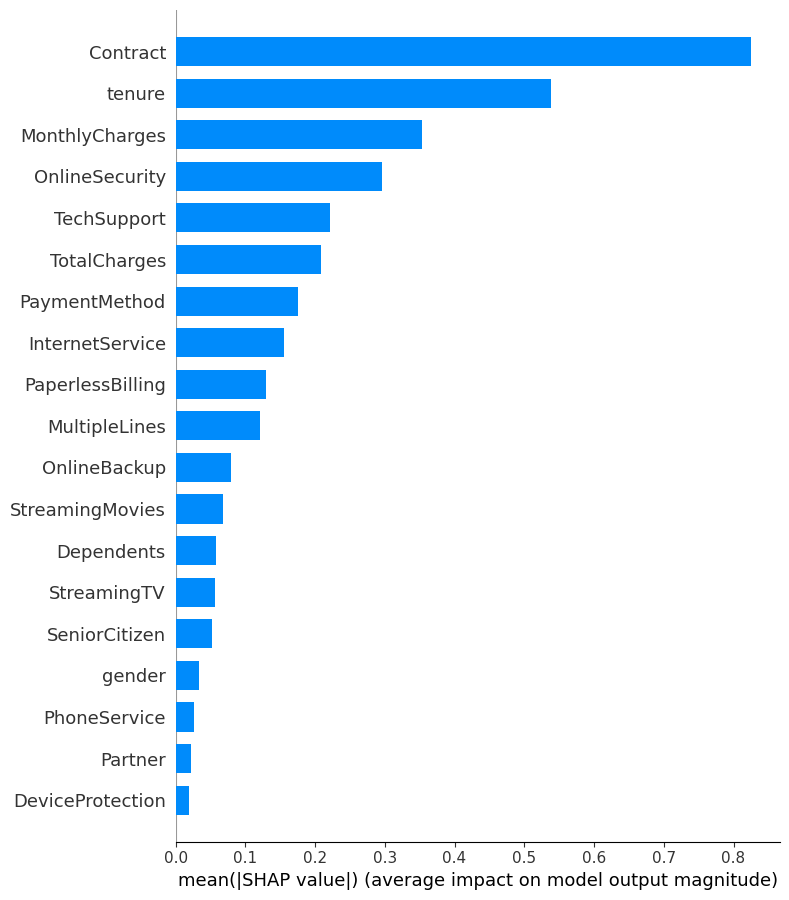

In [10]:
# Feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png')
plt.show()

In [11]:
# Modeli kaydet
os.makedirs('../src', exist_ok=True)
joblib.dump(model, '../src/model.pkl')
X.to_csv('../data/processed/features.csv', index=False)
print("Model kaydedildi.")

Model kaydedildi.
